# 05 — Modélisation : Statistiques et Prophet

## Projet : Smart City Energy Forecasting — Tetouan

**Correspondance méthodologique :** Ce notebook couvre l'étape **12.1 à 12.3** de la méthodologie KDD (Data Mining / Modeling).

### Objectifs

- Évaluer une Baseline Naïve (Modèle 0).
- Entraîner et évaluer un modèle SARIMA univarié et un modèle SARIMAX multivarié (Modèle 1).
- Entraîner et évaluer un modèle Prophet (Modèle 2).
- Comparer les performances de ces modèles classiques pour établir une base solide avant le Machine Learning.

## 1. Imports et configuration

Nous utilisons les modules de notre architecture logicielle dans `src/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Résolution du chemin projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.models_baseline import evaluate_naive_baselines
from src.models_sarima import (
    SarimaConfig,
    run_sarima_experiment,
    save_sarima_outputs,
    DEFAULT_SARIMAX_EXOG_COLS,
)
from src.models_prophet import (
    ProphetConfig,
    run_prophet_experiment,
    save_prophet_outputs,
    make_prophet_holidays,
    DEFAULT_PROPHET_REGRESSORS,
)

# Chemins du projet
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_PRED_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"

FEATURES_PATH = PROCESSED_DIR / "tetouan_features.csv"

for path in [RESULTS_METRICS_DIR, RESULTS_PRED_DIR, RESULTS_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", PROJECT_ROOT)

Racine du projet : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan


## 2. Chargement des données

Nous chargeons les features générées à l'étape précédente.

In [2]:
print(f"Chargement de {FEATURES_PATH}...")
df = pd.read_csv(FEATURES_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime").sort_index()

print(f"Dimensions : {df.shape}")
print(f"Période : {df.index.min()} à {df.index.max()}")

# Séparation temporelle train/test classique (70% train, 15% val, 15% test)
# Ici, on va simplifier l'expérience avec train/test pour comparer.
train_size = int(len(df) * 0.85)  # Combiner Train+Val pour l'entraînement statistique
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Train : {len(df_train)} observations")
print(f"Test : {len(df_test)} observations")

TARGET = "target"

Chargement de C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\tetouan_features.csv...
Dimensions : (8568, 111)
Période : 2017-01-08 00:00:00 à 2017-12-30 23:00:00
Train : 7282 observations
Test : 1286 observations


## 12.1 Modèle 0 — Naive Forecast

La baseline naïve sert de **minimum de performance**. Un modèle complexe qui ne dépasse pas cette baseline n'a pas d'intérêt métier.

In [3]:
baseline_metrics, baseline_predictions = evaluate_naive_baselines(
    df,
    target_col=TARGET,
    train_ratio=0.70,
    val_ratio=0.15,
)

print("Métriques des baselines naïves :")
display(baseline_metrics)

Métriques des baselines naïves :


,model,n_test_obs,MAE,RMSE,MAPE,R2
0,naive_previous_week,1286,792.878790,1098.376378,2.781035,0.966537
1,naive_previous_day,1286,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,1286,1745.006648,2300.125141,6.015784,0.853255


## 12.2 Modèle 1 — SARIMA et SARIMAX

SARIMA modélise la série temporelle par autocorrélation, différenciation et moyenne mobile, avec une composante saisonnière.
SARIMAX ajoute des variables exogènes météo ou calendaires.

**Attention :** SARIMAX est coûteux en temps de calcul sur de longues séries. Nous utiliserons le paramètre `max_train_size` (ex: 2000 points, env. 3 mois) pour l'entraînement.

In [4]:
# 1. SARIMA univarié (sans variables exogènes)
config_sarima = SarimaConfig(
    model_name="sarima_univariate",
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),  # Saisonnalité journalière
    trend="c",
    max_train_size=2000,
    use_exog=False
)

print("Entraînement SARIMA univarié...")
metrics_sarima, pred_sarima, model_sarima = run_sarima_experiment(
    train_df=df_train,
    test_df=df_test,
    target_col=TARGET,
    config=config_sarima
)

display(pd.DataFrame([metrics_sarima]))

Entraînement SARIMA univarié...


,model,model_family,n_train_obs,n_test_obs,order,seasonal_order,use_exog,n_exog_cols,MAE,RMSE,MAPE,R2
0,sarima_univariate,SARIMA/SARIMAX,2000,1286,"(1, 0, 1)","(1, 0, 1, 24)",False,0,8207.695998,9780.663928,33.286568,-1.653365


In [5]:
# 2. SARIMAX multivarié (avec météo et calendrier)
config_sarimax = SarimaConfig(
    model_name="sarimax_multivariate",
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    trend="c",
    max_train_size=2000,
    use_exog=True,
    scale_exog=True
)

exog_features = [col for col in DEFAULT_SARIMAX_EXOG_COLS if col in df.columns]

print("Entraînement SARIMAX multivarié...")
metrics_sarimax, pred_sarimax, model_sarimax = run_sarima_experiment(
    train_df=df_train,
    test_df=df_test,
    target_col=TARGET,
    config=config_sarimax,
    exog_cols=exog_features
)

display(pd.DataFrame([metrics_sarimax]))

Entraînement SARIMAX multivarié...


,model,model_family,n_train_obs,n_test_obs,order,seasonal_order,use_exog,n_exog_cols,MAE,RMSE,MAPE,R2
0,sarimax_multivariate,SARIMA/SARIMAX,2000,1286,"(1, 0, 1)","(1, 0, 1, 24)",True,17,2499.567275,3105.184215,8.967039,0.732555


## 12.3 Modèle 2 — Prophet

Prophet modélise une série comme la somme d'une tendance, de saisonnalités et d'effets événementiels.
Il gère très bien les jours spéciaux (jours fériés).

In [6]:
prophet_config = ProphetConfig(
    model_name="prophet_multivariate",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"
)

prophet_exog = [col for col in DEFAULT_PROPHET_REGRESSORS if col in df.columns]
holidays_df = make_prophet_holidays(df_train, holiday_col="is_holiday")

print("Entraînement Prophet avec régresseurs...")
metrics_prophet, pred_prophet, forecast_df, model_prophet = run_prophet_experiment(
    train_df=df_train,
    test_df=df_test,
    target_col=TARGET,
    config=prophet_config,
    regressor_cols=prophet_exog,
    holidays=holidays_df
)

display(pd.DataFrame([metrics_prophet]))

Entraînement Prophet avec régresseurs...


00:11:33 - cmdstanpy - INFO - Chain [1] start processing
00:11:34 - cmdstanpy - INFO - Chain [1] done processing


,model,model_family,n_train_obs,n_test_obs,yearly_seasonality,weekly_seasonality,daily_seasonality,seasonality_mode,n_regressors,MAE,RMSE,MAPE,R2
0,prophet_multivariate,Prophet,7282,1286,True,True,True,additive,11,33774.309334,38232.39176,121.310736,-39.543691


## 12.4 Comparaison des performances

Regroupons les résultats de la Baseline, SARIMA(X) et Prophet pour évaluer quelle approche fournit la meilleure précision.

In [7]:
all_metrics = pd.concat([
    baseline_metrics,
    pd.DataFrame([metrics_sarima]),
    pd.DataFrame([metrics_sarimax]),
    pd.DataFrame([metrics_prophet])
], ignore_index=True)

# Sauvegarder les métriques globales de l'expérimentation statistique
all_metrics.to_csv(RESULTS_METRICS_DIR / "statistical_models_metrics.csv", index=False)

all_metrics_sorted = all_metrics.sort_values("MAPE")
display(all_metrics_sorted[["model", "MAE", "RMSE", "MAPE", "R2"]])

,model,MAE,RMSE,MAPE,R2
0,naive_previous_week,792.878790,1098.376378,2.781035,0.966537
1,naive_previous_day,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,1745.006648,2300.125141,6.015784,0.853255
4,sarimax_multivariate,2499.567275,3105.184215,8.967039,0.732555
3,sarima_univariate,8207.695998,9780.663928,33.286568,-1.653365
5,prophet_multivariate,33774.309334,38232.391760,121.310736,-39.543691


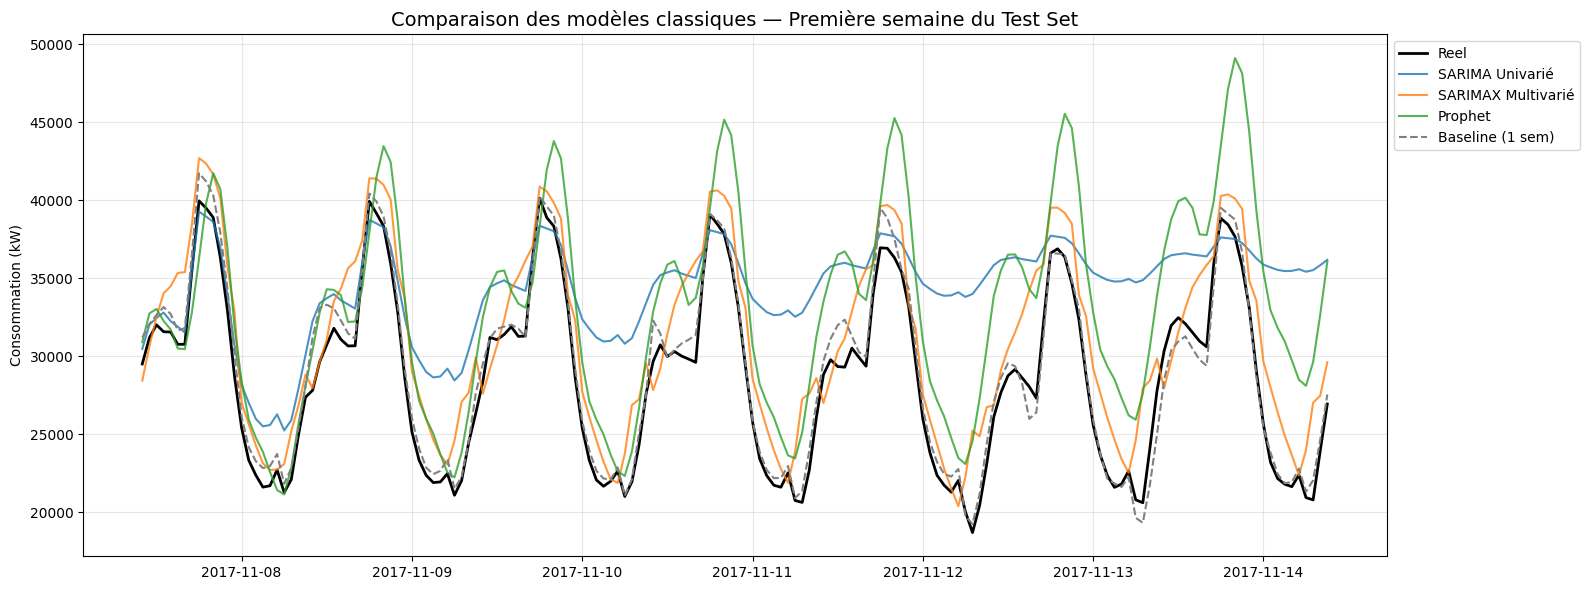

In [8]:
# Visualisation sur la première semaine de test
fig, ax = plt.subplots(figsize=(16, 6))

plot_df = df_test.iloc[:24*7].copy()
ax.plot(plot_df.index, plot_df[TARGET], label="Reel", color="black", linewidth=2)

ax.plot(plot_df.index, pred_sarima.iloc[:24*7], label="SARIMA Univarié", alpha=0.8)
ax.plot(plot_df.index, pred_sarimax.iloc[:24*7], label="SARIMAX Multivarié", alpha=0.8)
ax.plot(plot_df.index, pred_prophet.iloc[:24*7], label="Prophet", alpha=0.8)
ax.plot(plot_df.index, baseline_predictions["naive_previous_week"].loc[plot_df.index], label="Baseline (1 sem)", linestyle="--", color="grey")

ax.set_title("Comparaison des modèles classiques — Première semaine du Test Set", fontsize=14)
ax.set_ylabel("Consommation (kW)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "statistical_models_test_week.png", dpi=150)
plt.show()

## Conclusion de la modélisation statistique

- **Baseline hebdomadaire** : Souvent extrêmement robuste sur des séries saisonnières fortement répétitives.
- **SARIMAX / Prophet** : Si le MAPE n'est pas significativement meilleur (ou est même moins bon) que la baseline, cela indique que la complexité des modèles n'est pas compensée par les features linéaires et les saisonnalités. 
- L'étape suivante consistera à exploiter toute la puissance du **Feature Engineering non-linéaire** via des modèles de Machine Learning (XGBoost) et Deep Learning (GRU) pour tenter d'écraser la baseline.